In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2026-01-15 14:09:24.386710


# QC Filters

**Pinned Environment:** [`envs/sc-spatial.yaml`](../.../envs/sc-spatial.yaml)  

In [2]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import anndata as ad
import scanpy as sc
import sys

### Set paths, import data

In [3]:
sys.path.append(str(Path.cwd().resolve().parents[1]))

from config.paths import BASE_DIR
base_dir = BASE_DIR

input_dir = base_dir / "data/h5ad/export_01/01a_raw/output_folder"
output_dir = base_dir / "data/h5ad/export_01/01b_filter"

output_dir.mkdir(parents=True, exist_ok=True)

Make a list of files in the directory:

In [4]:
sample_list = os.listdir(input_dir)
sample_list

['TMA00317.h5ad', 'TMA00315.h5ad', 'TMA00318.h5ad', 'TMA00316.h5ad']

Add samples to list if they end in .h5ad:

In [5]:
sample_files = [
    os.path.join(input_dir, f)
    for f in os.listdir(input_dir)
    if f.endswith(".h5ad") and f.startswith("TMA")
]

adata_list = [ad.read_h5ad(f) for f in sample_files]

for f, adata in zip(sample_files, adata_list):
    print(f"{os.path.basename(f)} > {adata.n_obs:,} cells × {adata.n_vars:,} genes")

TMA00317.h5ad > 21,723 cells × 480 genes
TMA00315.h5ad > 25,867 cells × 480 genes
TMA00318.h5ad > 22,761 cells × 480 genes
TMA00316.h5ad > 26,319 cells × 480 genes


## Filter

Filtering based on total cell count thresholds from Max's paper.

In [6]:
def plot_violin_subplots(adata_list, obs_keys):
    n = len(adata_list)
    fig, axs = plt.subplots(1, n, figsize=(6 * n, 5))

    if n == 1:
        axs = [axs]  # make iterable if only one sample

    for ax, adata in zip(axs, adata_list):
        sc.pl.violin(adata, obs_keys, show=False, ax=ax)
        ax.set_title(getattr(adata, "filename", "Sample"))

    plt.tight_layout()
    plt.show()

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` 

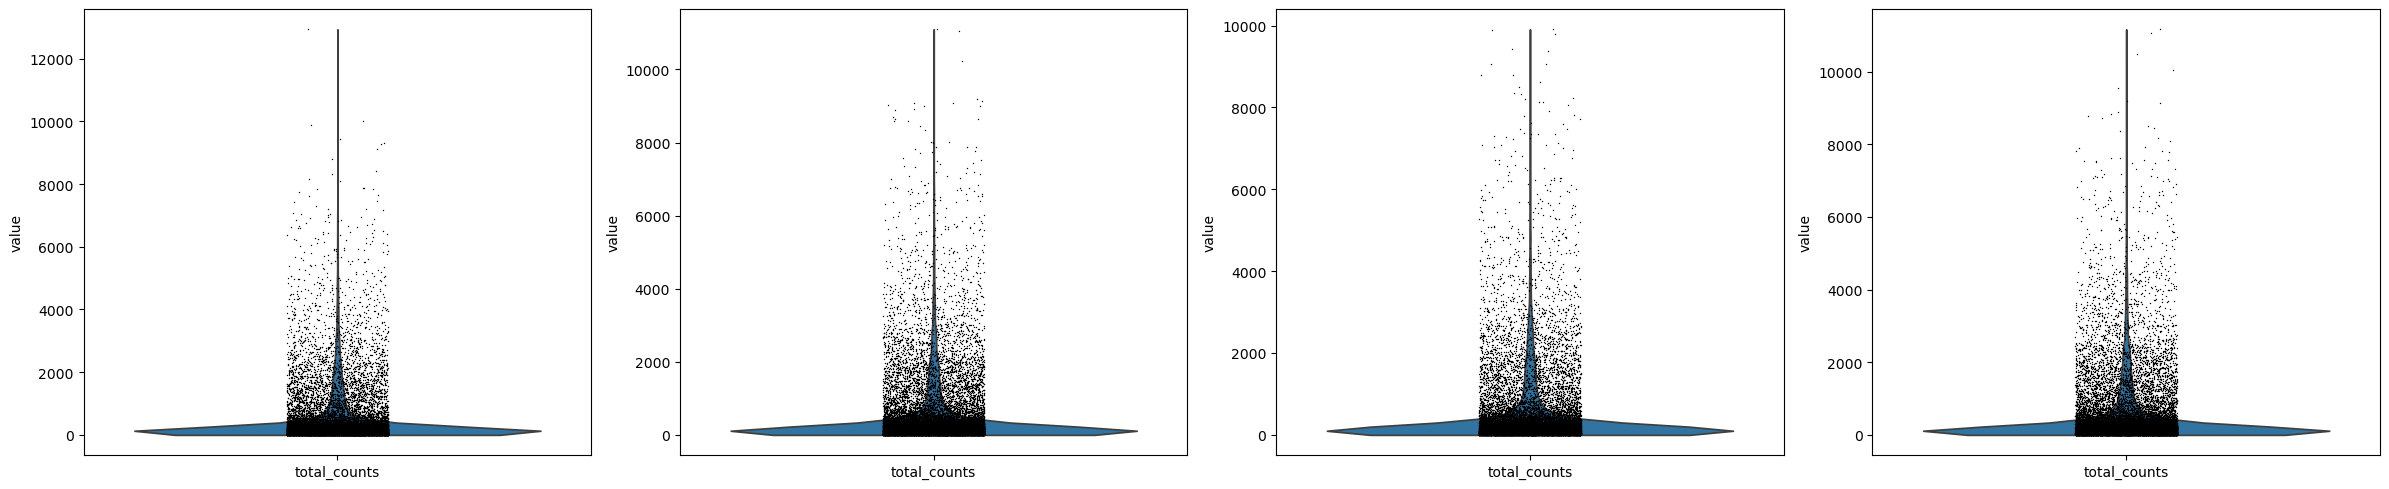

In [7]:
plot_violin_subplots(adata_list, ["total_counts"])

In [8]:
# Total counts – Floor threshold
for i, adata in enumerate(adata_list):
    sample_id = adata.obs["sample_id"].unique()[0]
    print(f"{sample_id} shape before total_counts floor threshold: {adata.shape}")
    adata_list[i] = adata[adata.obs["total_counts"] > 50].copy()
    print(
        f"{sample_id} shape after total_counts floor threshold: {adata_list[i].shape}"
    )

TMA00317 shape before total_counts floor threshold: (21723, 480)
TMA00317 shape after total_counts floor threshold: (16366, 480)
TMA00315 shape before total_counts floor threshold: (25867, 480)
TMA00315 shape after total_counts floor threshold: (19474, 480)
TMA00318 shape before total_counts floor threshold: (22761, 480)
TMA00318 shape after total_counts floor threshold: (17127, 480)
TMA00316 shape before total_counts floor threshold: (26319, 480)
TMA00316 shape after total_counts floor threshold: (19995, 480)


In [9]:
# Total counts - ceiling threshold
for i, adata in enumerate(adata_list):
    sample_id = adata.obs["sample_id"].unique()[0]
    print(f"{sample_id} shape before total_counts ceiling threshold: {adata.shape}")
    total_counts_ceiling = adata.obs["total_counts"].quantile(0.9975)
    adata_list[i] = adata[adata.obs["total_counts"] < total_counts_ceiling, :].copy()
    print(
        f"{sample_id} shape after total_counts ceiling threshold: {adata_list[i].shape}"
    )

TMA00317 shape before total_counts ceiling threshold: (16366, 480)
TMA00317 shape after total_counts ceiling threshold: (16325, 480)
TMA00315 shape before total_counts ceiling threshold: (19474, 480)
TMA00315 shape after total_counts ceiling threshold: (19425, 480)
TMA00318 shape before total_counts ceiling threshold: (17127, 480)
TMA00318 shape after total_counts ceiling threshold: (17084, 480)
TMA00316 shape before total_counts ceiling threshold: (19995, 480)
TMA00316 shape after total_counts ceiling threshold: (19944, 480)


/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` 

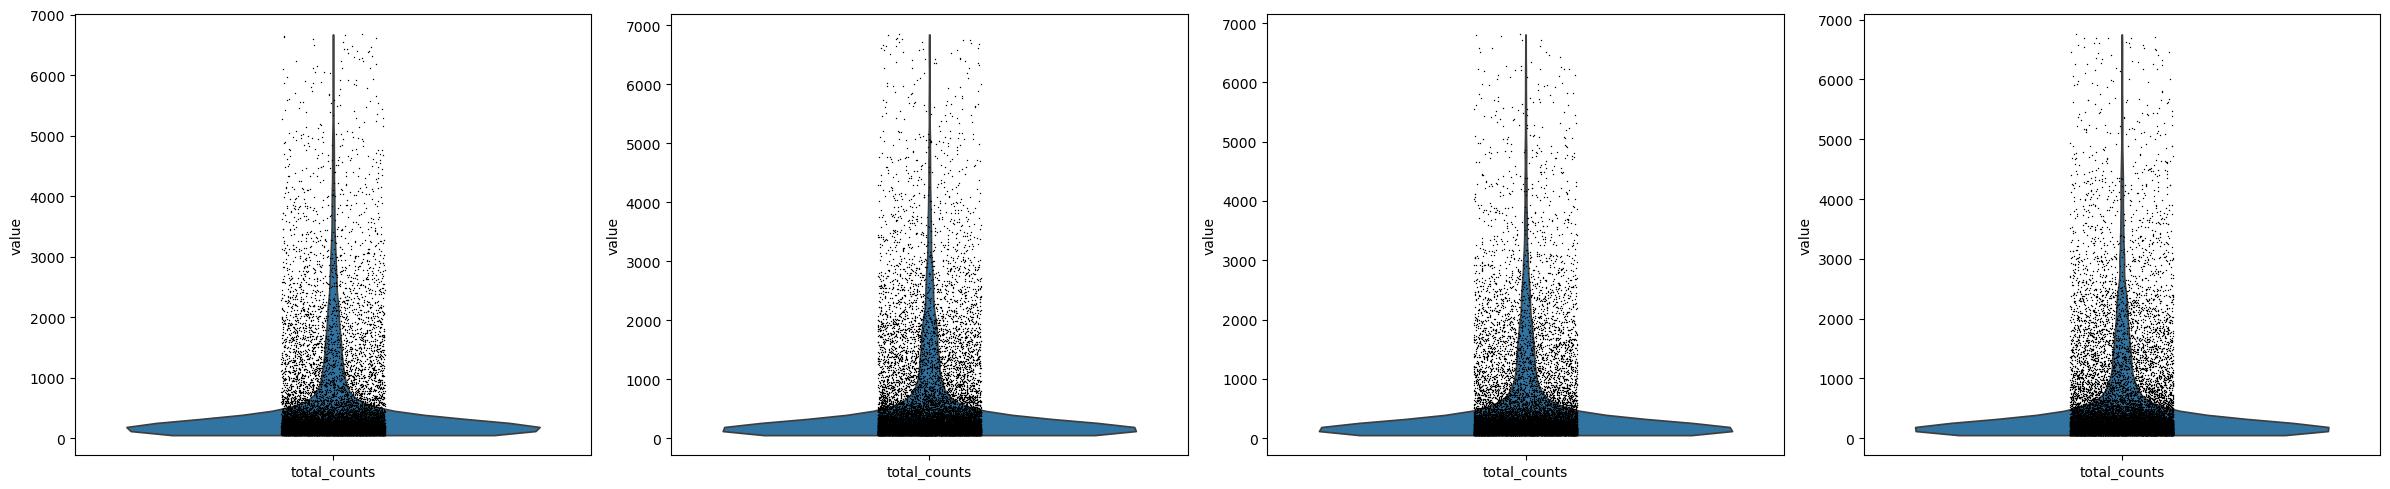

In [10]:
plot_violin_subplots(adata_list, ["total_counts"])

## Concatenate

In [11]:
adata = ad.concat(adata_list, join="outer", label="batch", index_unique="-")

In [12]:
adata.obs.sample_id.value_counts()

sample_id
TMA00316    19944
TMA00315    19425
TMA00318    17084
TMA00317    16325
Name: count, dtype: int64

## Normalization

In [13]:
adata.layers["counts"] = adata.X.copy()

In [14]:
def remove_transgenes(adata, pattern="Seq"):
    print(f"\nProcessing: {getattr(adata, 'uns', {}).get('name', 'AnnData')}")
    print(f"Initial # genes: {adata.n_vars}")

    # Identify transgenes (always exactly five)
    transgenes = adata.var_names[
        adata.var_names.str.contains(pattern, case=False, na=False)
    ]
    print(f"Transgenes: {list(transgenes)}")

    # Remove them
    adata_filtered = adata[:, ~adata.var_names.isin(transgenes)].copy()
    print(f"Remaining genes: {adata_filtered.n_vars}")

    return adata_filtered


adata_subset = remove_transgenes(adata, pattern="Seq")


Processing: AnnData
Initial # genes: 480
Transgenes: ['Cre_Seq5', 'EGFP_Seq1', 'Flp_Seq4', 'mCherry_Seq3', 'tdTomato_Seq2']
Remaining genes: 475


In [15]:
sc.pp.normalize_total(adata_subset)
adata_subset.layers["normalized"] = adata_subset.X.copy()

sc.pp.log1p(adata_subset)
adata_subset.raw = adata_subset.copy()
adata_subset.layers["log1p"] = adata_subset.X.copy()

In [16]:
print(adata.layers)
print(adata_subset.layers)

Layers with keys: counts
Layers with keys: counts, normalized, log1p


## Export

In [17]:
# 480 genes
filename = os.path.join(output_dir, "adata-480.h5ad")
os.makedirs(os.path.dirname(filename), exist_ok=True)
adata.write_h5ad(filename, compression="gzip")
print(f"Filtered AnnData with all genes saved to: {filename}")

# 475 genes
filename = os.path.join(output_dir, "adata-475.h5ad")
os.makedirs(os.path.dirname(filename), exist_ok=True)
adata_subset.write_h5ad(filename, compression="gzip")
print(f"Filtered AnnData without transgenes saved to: {filename}")

Filtered AnnData with all genes saved to: /home/workspace/projects/drg/data/h5ad/export_01/01b_filter/adata-480.h5ad
Filtered AnnData without transgenes saved to: /home/workspace/projects/drg/data/h5ad/export_01/01b_filter/adata-475.h5ad
